In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 0. Import database

In [2]:
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Importa Base, separação por tabulação
base = pd.read_csv(url, sep="\t", encoding="Latin-1")

# Cria uma lista com os nomes das colunas
header = ['ID_CLIENTE', 'TIPO_FUNCIONARIO', 'DIA_PAGAMENTO', 'TIPO_ENVIO_APLICACAO', 'QUANT_CARTOES_ADICIONAIS',
          'TIPO_ENDERECO_POSTAL', 'SEXO', 'ESTADO_CIVIL', 'QUANT_DEPENDENTES', 'NIVEL_EDUCACIONAL', 'ESTADO_NASCIMENTO',
          'CIDADE_NASCIMENTO', 'NACIONALIDADE', 'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL',
          'FLAG_TELEFONE_RESIDENCIAL', 'CODIGO_AREA_TELEFONE_RESIDENCIAL', 'TIPO_RESIDENCIA', 'MESES_RESIDENCIA',
          'FLAG_TELEFONE_MOVEL', 'FLAG_EMAIL', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'FLAG_VISA', 'FLAG_MASTERCARD',
          'FLAG_DINERS', 'FLAG_AMERICAN_EXPRESS', 'FLAG_OUTROS_CARTOES', 'QUANT_CONTAS_BANCARIAS',
          'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'EMPRESA',
          'ESTADO_PROFISSIONAL', 'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL',
          'CODIGO_AREA_TELEFONE_PROFISSIONAL', 'MESES_NO_TRABALHO', 'CODIGO_PROFISSAO', 'TIPO_OCUPACAO',
          'CODIGO_PROFISSAO_CONJUGE', 'NIVEL_EDUCACIONAL_CONJUGE', 'FLAG_DOCUMENTO_RESIDENCIAL', 'FLAG_RG',
          'FLAG_CPF', 'FLAG_COMPROVANTE_RENDA', 'PRODUTO', 'FLAG_REGISTRO_ACSP', 'IDADE', 'CEP_RESIDENCIAL_3',
          'CEP_PROFISSIONAL_3', 'ROTULO_ALVO_MAU=1'
]

# Adiciona nome as colunas do data frame
base.columns = header
base

C:\Users\ivan_\AppData\Local\Temp\ipykernel_31568\158269861.py:4: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  base = pd.read_csv(url, sep="\t", encoding="Latin-1")


,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU=1
0,2,C,15,Carga,0,1,F,2,0,0,...,0,0,0,0,1,N,34,230,230,1
1,3,C,5,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,27,591,591,0
2,4,C,20,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,61,545,545,0
3,5,C,10,Web,0,1,M,2,0,0,...,0,0,0,0,1,N,48,235,235,1
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996,C,10,0,0,1,F,1,2,0,...,0,0,0,0,1,N,36,591,591,1
49995,49997,C,25,0,0,1,F,1,0,0,...,0,0,0,0,2,N,21,186,186,0
49996,49998,C,5,Web,0,1,M,2,3,0,...,0,0,0,0,1,N,41,715,715,0
49997,49999,C,1,Web,0,1,F,1,1,0,...,0,0,0,0,1,N,28,320,320,1


In [3]:
base.to_csv("base.csv")

In [4]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID_CLIENTE                         49999 non-null  int64  
 1   TIPO_FUNCIONARIO                   49999 non-null  object 
 2   DIA_PAGAMENTO                      49999 non-null  int64  
 3   TIPO_ENVIO_APLICACAO               49999 non-null  object 
 4   QUANT_CARTOES_ADICIONAIS           49999 non-null  int64  
 5   TIPO_ENDERECO_POSTAL               49999 non-null  int64  
 6   SEXO                               49999 non-null  object 
 7   ESTADO_CIVIL                       49999 non-null  int64  
 8   QUANT_DEPENDENTES                  49999 non-null  int64  
 9   NIVEL_EDUCACIONAL                  49999 non-null  int64  
 10  ESTADO_NASCIMENTO                  49999 non-null  object 
 11  CIDADE_NASCIMENTO                  49999 non-null  obj

# 3. Teste-03

## 3.1 Tratamentos dos dados

In [5]:
base["SEXO"].value_counts()

SEXO
F    30804
M    19130
N       48
        17
Name: count, dtype: int64

In [6]:
base = base[base['SEXO'] != 'N']

# Depois, remover linhas onde SEXO é vazio ou nulo
base = base[base['SEXO'].notna()]    # remove nulos (NaN)
base = base[base['SEXO'].str.strip() != '']  # remove strings vazias ou só com espaços

In [7]:
base["SEXO"].value_counts()

SEXO
F    30804
M    19130
Name: count, dtype: int64

In [8]:
base["TIPO_RESIDENCIA"].value_counts()

TIPO_RESIDENCIA
1.0    41516
2.0     3880
5.0     1980
0.0      757
4.0      311
3.0      141
Name: count, dtype: int64

In [9]:
base["TIPO_ENVIO_APLICACAO"].value_counts()

TIPO_ENVIO_APLICACAO
Web      28202
0        19400
Carga     2332
Name: count, dtype: int64

In [10]:
base["QUANT_CARTOES_ADICIONAIS"].value_counts()

QUANT_CARTOES_ADICIONAIS
0    49934
Name: count, dtype: int64

In [11]:
base["TIPO_ENDERECO_POSTAL"].value_counts()

TIPO_ENDERECO_POSTAL
1    49607
2      327
Name: count, dtype: int64

In [12]:
base["ESTADO_CIVIL"].value_counts()

ESTADO_CIVIL
2    25929
1    15270
4     4201
6     1874
5     1294
3      632
7      534
0      200
Name: count, dtype: int64

In [13]:
base["QUANT_DEPENDENTES"].value_counts()

QUANT_DEPENDENTES
0     33615
1      6993
2      5352
3      2463
4       859
5       365
6       138
7        65
8        35
9        14
10       13
11        7
12        6
13        4
14        3
15        1
53        1
Name: count, dtype: int64

In [14]:
base["NIVEL_EDUCACIONAL"].value_counts()

NIVEL_EDUCACIONAL
0    49934
Name: count, dtype: int64

In [15]:
base["NACIONALIDADE"].value_counts()

NACIONALIDADE
1    47820
0     2016
2       98
Name: count, dtype: int64

In [16]:
base["MESES_RESIDENCIA"].value_counts()

MESES_RESIDENCIA
1.0      7335
0.0      4687
10.0     3795
5.0      3558
2.0      3211
         ... 
101.0       1
66.0        1
78.0        1
81.0        1
89.0        1
Name: count, Length: 88, dtype: int64

In [17]:
base["QUANT_CONTAS_BANCARIAS"].value_counts()

QUANT_CONTAS_BANCARIAS
0    32111
1    17809
2       14
Name: count, dtype: int64

In [18]:
base["QUANT_CONTAS_BANCARIAS_ESPECIAIS"].value_counts()

QUANT_CONTAS_BANCARIAS_ESPECIAIS
0    32111
1    17809
2       14
Name: count, dtype: int64

In [19]:
base["VALOR_PATRIMONIO_PESSOAL"].value_counts()

VALOR_PATRIMONIO_PESSOAL
0.0          47546
30000.0        222
25000.0        198
50000.0        196
15000.0        185
             ...  
5000000.0        1
220000.0         1
53000.0          1
401.0            1
10500.0          1
Name: count, Length: 153, dtype: int64

In [20]:
base["QUANT_CARROS"].value_counts()

QUANT_CARROS
0    33188
1    16746
Name: count, dtype: int64

In [21]:
base["CODIGO_PROFISSAO"].value_counts()

CODIGO_PROFISSAO
9.0     30052
11.0     3540
0.0      3530
2.0      2821
12.0      487
10.0      425
16.0      343
13.0      312
7.0       216
8.0       144
6.0       136
15.0       63
17.0       35
4.0        27
3.0        18
5.0        12
14.0        9
1.0         8
18.0        1
Name: count, dtype: int64

In [22]:
base["TIPO_OCUPACAO"].value_counts()

TIPO_OCUPACAO
2.0    16926
1.0     8732
4.0     6985
5.0     6881
0.0     2779
3.0      318
Name: count, dtype: int64

In [23]:
base["FLAG_COMPROVANTE_RENDA"].value_counts()

FLAG_COMPROVANTE_RENDA
0    49934
Name: count, dtype: int64

In [24]:
base["PRODUTO"].value_counts()

PRODUTO
1    42633
2     6011
7     1290
Name: count, dtype: int64

In [25]:
base["TEM_CARTAO"] = base[['FLAG_VISA',
                                'FLAG_MASTERCARD',
                                'FLAG_DINERS',
                                'FLAG_AMERICAN_EXPRESS',
                                'FLAG_OUTROS_CARTOES']].any(axis=1)
base["TEM_CARTAO"].value_counts()

TEM_CARTAO
False    41751
True      8183
Name: count, dtype: int64

In [26]:
base["RENDA_TOTAL"] = base["RENDA_PESSOAL_MENSAL"] + base["OUTRAS_RENDAS"]
base["RENDA_TOTAL"].describe()

count     49934.000000
mean        922.350702
std        7902.643552
min          60.000000
25%         372.000000
50%         515.000000
75%         840.000000
max      959000.000000
Name: RENDA_TOTAL, dtype: float64

In [27]:
lista_drop_features=[
    "ID_CLIENTE",
    "TIPO_FUNCIONARIO",
    "DIA_PAGAMENTO",
    "TIPO_ENVIO_APLICACAO",
    "QUANT_CARTOES_ADICIONAIS",
    "TIPO_ENDERECO_POSTAL",
    "NIVEL_EDUCACIONAL",
    "ESTADO_NASCIMENTO",
    "CIDADE_NASCIMENTO",
    "NACIONALIDADE",
    "ESTADO_RESIDENCIAL",
    "CIDADE_RESIDENCIAL",
    "BAIRRO_RESIDENCIAL",
    "BAIRRO_PROFISSIONAL",
    "FLAG_TELEFONE_RESIDENCIAL",
    "CODIGO_AREA_TELEFONE_RESIDENCIAL",
    "MESES_RESIDENCIA",
    "FLAG_TELEFONE_MOVEL",
    "FLAG_EMAIL",
    "QUANT_CONTAS_BANCARIAS_ESPECIAIS",
    "VALOR_PATRIMONIO_PESSOAL",
    #"QUANT_CARROS",
    "EMPRESA",
    "ESTADO_PROFISSIONAL",
    "CIDADE_PROFISSIONAL",
    "BAIRRO_PROFISSIONAL",
    "FLAG_TELEFONE_PROFISSIONAL",
    "CODIGO_AREA_TELEFONE_PROFISSIONAL",
    "MESES_NO_TRABALHO",
    "CODIGO_PROFISSAO",
    "CODIGO_PROFISSAO_CONJUGE",
    "NIVEL_EDUCACIONAL_CONJUGE",
    "FLAG_DOCUMENTO_RESIDENCIAL",
    "FLAG_RG",
    "FLAG_CPF",
    "FLAG_COMPROVANTE_RENDA",
    "FLAG_REGISTRO_ACSP",
    "CEP_RESIDENCIAL_3",
    "CEP_PROFISSIONAL_3",
    "QUANT_CONTAS_BANCARIAS",
    'FLAG_VISA',
    'FLAG_MASTERCARD',
    'FLAG_DINERS',
    'FLAG_AMERICAN_EXPRESS',
    'FLAG_OUTROS_CARTOES',
    "RENDA_PESSOAL_MENSAL",
    "OUTRAS_RENDAS"
    #"TIPO_RESIDENCIA"
    ]

In [28]:
base = base.drop(columns=lista_drop_features)

In [29]:
base.isnull().sum()

SEXO                    0
ESTADO_CIVIL            0
QUANT_DEPENDENTES       0
TIPO_RESIDENCIA      1349
QUANT_CARROS            0
TIPO_OCUPACAO        7313
PRODUTO                 0
IDADE                   0
ROTULO_ALVO_MAU=1       0
TEM_CARTAO              0
RENDA_TOTAL             0
dtype: int64

In [30]:
base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49934 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEXO               49934 non-null  object 
 1   ESTADO_CIVIL       49934 non-null  int64  
 2   QUANT_DEPENDENTES  49934 non-null  int64  
 3   TIPO_RESIDENCIA    48585 non-null  float64
 4   QUANT_CARROS       49934 non-null  int64  
 5   TIPO_OCUPACAO      42621 non-null  float64
 6   PRODUTO            49934 non-null  int64  
 7   IDADE              49934 non-null  int64  
 8   ROTULO_ALVO_MAU=1  49934 non-null  int64  
 9   TEM_CARTAO         49934 non-null  bool   
 10  RENDA_TOTAL        49934 non-null  float64
dtypes: bool(1), float64(3), int64(6), object(1)
memory usage: 4.2+ MB


In [31]:
base["RENDA_TOTAL"].describe()

count     49934.000000
mean        922.350702
std        7902.643552
min          60.000000
25%         372.000000
50%         515.000000
75%         840.000000
max      959000.000000
Name: RENDA_TOTAL, dtype: float64

Text(0, 0.5, 'Qte_dependentes')

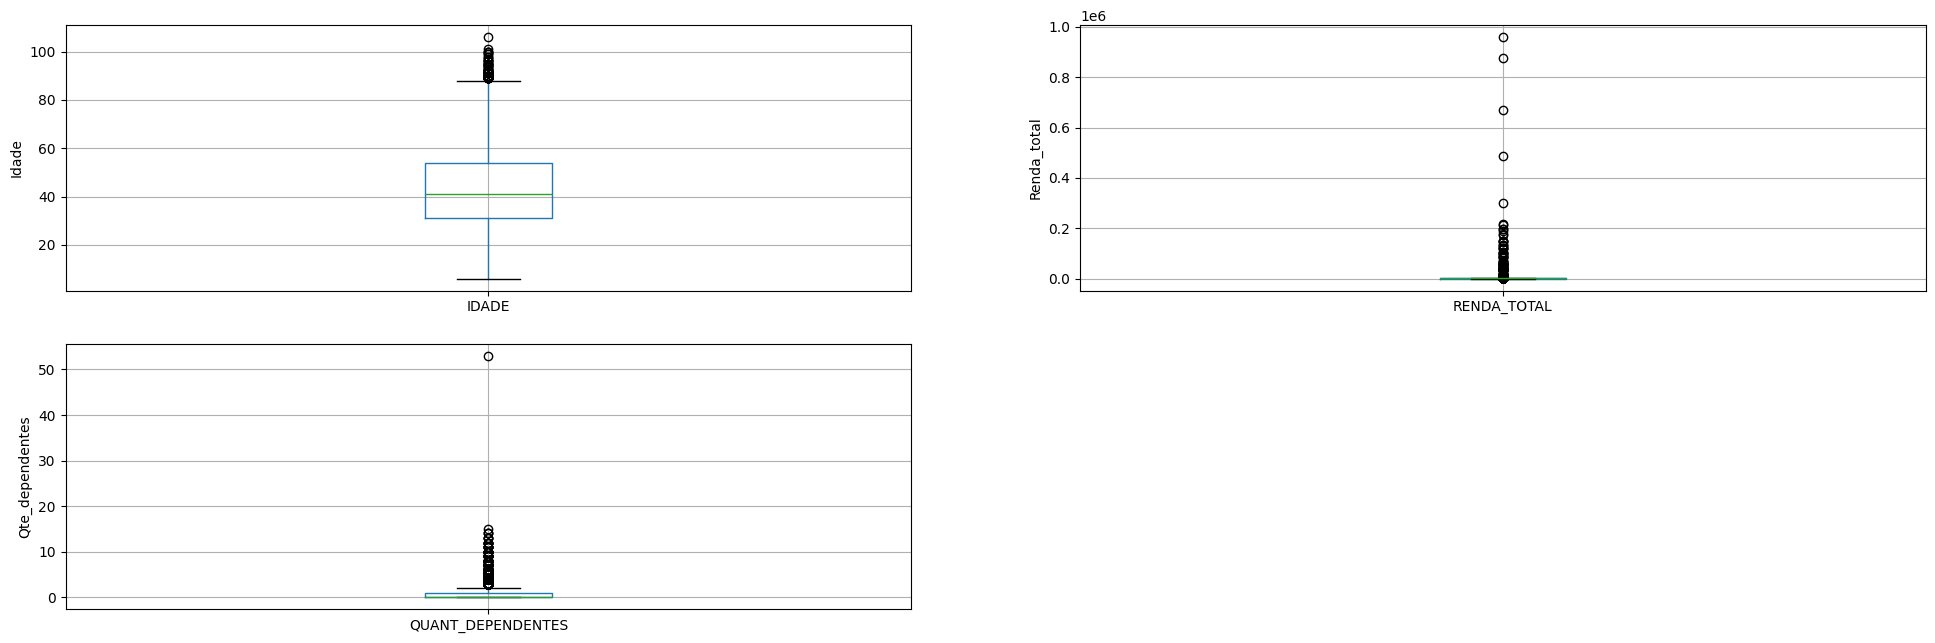

In [32]:
plt.figure(figsize=(24,20))

plt.subplot(5, 2, 1)
fig = base.boxplot(column='IDADE')
fig.set_title('')
fig.set_ylabel('Idade')

plt.subplot(5, 2, 2)
fig = base.boxplot(column='RENDA_TOTAL')
fig.set_title('')
fig.set_ylabel('Renda_total')

plt.subplot(5, 2, 3)
fig = base.boxplot(column='QUANT_DEPENDENTES')
fig.set_title('')
fig.set_ylabel('Qte_dependentes')

In [33]:
base["QUANT_DEPENDENTES"] = base["QUANT_DEPENDENTES"].apply(lambda x: 7 if x > 7 else x)
base['QUANT_DEPENDENTES'].value_counts()

QUANT_DEPENDENTES
0    33615
1     6993
2     5352
3     2463
4      859
5      365
7      149
6      138
Name: count, dtype: int64

In [34]:
base['IDADE'] = base['IDADE'].apply(lambda x: 85 if x > 85 else x)
base['IDADE'].value_counts()

IDADE
39    1297
36    1285
37    1265
40    1264
41    1251
      ... 
84      51
17      18
6        1
7        1
14       1
Name: count, Length: 72, dtype: int64

Text(0, 0.5, 'Qtd_dependentes')

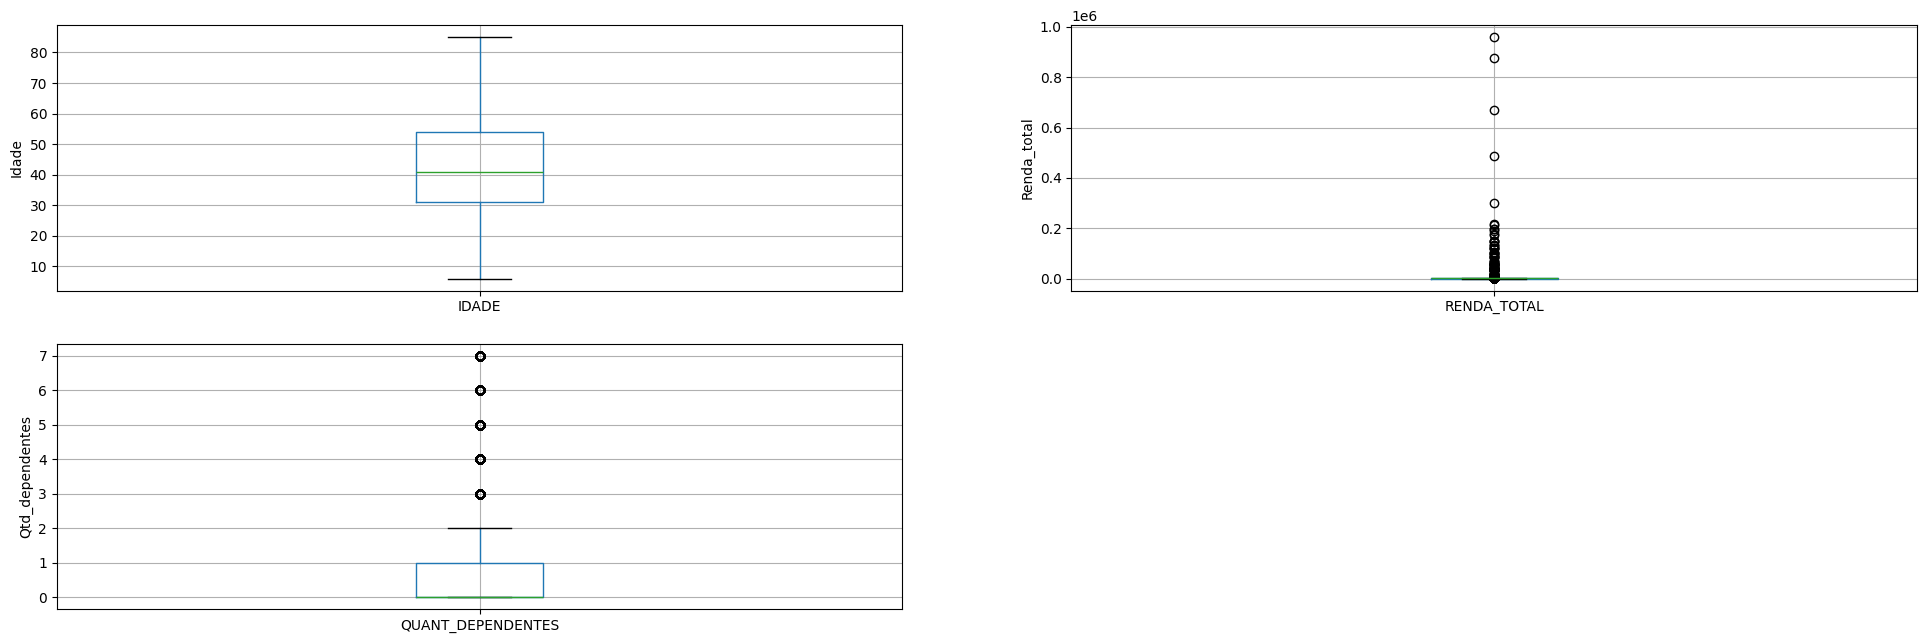

In [35]:
plt.figure(figsize=(24,20))

plt.subplot(5, 2, 1)
fig = base.boxplot(column='IDADE')
fig.set_title('')
fig.set_ylabel('Idade')

plt.subplot(5, 2, 2)
fig = base.boxplot(column='RENDA_TOTAL')
fig.set_title('')
fig.set_ylabel('Renda_total')

plt.subplot(5, 2, 3)
fig = base.boxplot(column='QUANT_DEPENDENTES')
fig.set_title('')
fig.set_ylabel('Qtd_dependentes')

In [36]:
base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49934 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEXO               49934 non-null  object 
 1   ESTADO_CIVIL       49934 non-null  int64  
 2   QUANT_DEPENDENTES  49934 non-null  int64  
 3   TIPO_RESIDENCIA    48585 non-null  float64
 4   QUANT_CARROS       49934 non-null  int64  
 5   TIPO_OCUPACAO      42621 non-null  float64
 6   PRODUTO            49934 non-null  int64  
 7   IDADE              49934 non-null  int64  
 8   ROTULO_ALVO_MAU=1  49934 non-null  int64  
 9   TEM_CARTAO         49934 non-null  bool   
 10  RENDA_TOTAL        49934 non-null  float64
dtypes: bool(1), float64(3), int64(6), object(1)
memory usage: 4.2+ MB


## 3.2 Separação das bases

In [37]:
base_numerica = base.select_dtypes(exclude=['object'])
base_objeto = base.select_dtypes(exclude=['int64', 'float64'])

In [38]:
base_objeto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49934 entries, 0 to 49998
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SEXO        49934 non-null  object
 1   TEM_CARTAO  49934 non-null  bool  
dtypes: bool(1), object(1)
memory usage: 829.0+ KB


## 3.3 SEXO Dummies

In [39]:
sexo = pd.get_dummies(base_objeto['SEXO'], drop_first=True)
sexo.head()

,M
0,False
1,False
2,False
3,True
4,True


In [40]:
base_numerica.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49934 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ESTADO_CIVIL       49934 non-null  int64  
 1   QUANT_DEPENDENTES  49934 non-null  int64  
 2   TIPO_RESIDENCIA    48585 non-null  float64
 3   QUANT_CARROS       49934 non-null  int64  
 4   TIPO_OCUPACAO      42621 non-null  float64
 5   PRODUTO            49934 non-null  int64  
 6   IDADE              49934 non-null  int64  
 7   ROTULO_ALVO_MAU=1  49934 non-null  int64  
 8   TEM_CARTAO         49934 non-null  bool   
 9   RENDA_TOTAL        49934 non-null  float64
dtypes: bool(1), float64(3), int64(6)
memory usage: 3.9 MB


## 3.4 Treinamento e Teste

In [41]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Transformações numéricas
        X['LOG_RENDA_TOTAL'] = np.log1p(X['RENDA_TOTAL'])
        X['RENDA_POR_DEPENDENTE'] = X['RENDA_TOTAL'] / (X['QUANT_DEPENDENTES'] + 1)
        X['IDADE_RENDA'] = X['IDADE'] * X['RENDA_TOTAL']

        # Binning de idade
        X['IDADE_CAT'] = pd.cut(X['IDADE'], bins=[0, 18, 30, 45, 60, 80], labels=["0-18","18-30", "31-45", "46-60", "61-80"])
        X = X.drop(columns=['IDADE'])

        # Variável de interação
        #X['solteiro_jovem'] = ((X['ESTADO_CIVIL'] == 'Solteiro') & (X['idade'] < 30)).astype(int)

        return X


In [42]:
# Separando os tipos de variáveis
#num_features = ['QUANT_DEPENDENTES', 'QUANT_CARROS', 'IDADE', 'RENDA_TOTAL', 'log_renda', 'renda_per_dependente', 'idade_renda']
#cat_features = ['ESTADO_CIVIL', 'SEXO', 'TIPO_RESIDENCIA', 'TIPO_OCUPACAO', 'PRODUTO', 'TEM_CARTAO', 'idade_bin']

num_features = ['QUANT_DEPENDENTES', 'QUANT_CARROS', 'RENDA_TOTAL', 'LOG_RENDA_TOTAL', 'RENDA_POR_DEPENDENTE', 'IDADE_RENDA']
cat_features = ['ESTADO_CIVIL', 'SEXO', 'TIPO_RESIDENCIA', 'TIPO_OCUPACAO', 'PRODUTO', 'TEM_CARTAO', 'IDADE_CAT']

In [43]:
# Pipeline para variáveis numéricas
num_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),    # Imputação inteligente
    ('scaler', StandardScaler())               # Padronização
])

# Pipeline para variáveis categóricas
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Preencher nulos com a moda
    ('encoder', OneHotEncoder(drop='first'))
])

# Combinando tudo
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

In [44]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first'), cat_features)
])

In [45]:
pipeline = ImbPipeline([
    ('feature_engineering', FeatureEngineering()),                  # Criação de novas features
    ('preprocessing', preprocessor),                                # Novo preprocessor que trata num/cat separadamente
    ('smote', SMOTE(random_state=42)),                              # Balanceamento das classes
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)), # Seleção das melhores features
    #('model', LogisticRegression(class_weight='balanced', max_iter=1000))
    ('model', LogisticRegression(max_iter=1000))
])

In [46]:
# 5. Definindo o GridSearchCV para otimização de parâmetros
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],  # Testando diferentes valores para C (regularização)
    'feature_selection__k': [8, 10, 12, 14]    # Testando diferentes números de features selecionadas
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',      # Foco no recall
    cv=5,                  # 5-fold cross-validation
    n_jobs=-1,             # Usar todos os núcleos de processamento
    verbose=2
)

In [47]:
X = base.drop(columns=['ROTULO_ALVO_MAU=1'])
y = base['ROTULO_ALVO_MAU=1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [48]:
# 7. Treinando o modelo com GridSearch
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_engineering',
                                        FeatureEngineering()),
                                       ('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['QUANT_DEPENDENTES',
                                                                          'QUANT_CARROS',
                                                                          'RENDA_TOTAL',
                                                                          'LOG_RENDA_TOTAL',
                                                                          'RENDA_POR_DEPENDENTE',
                                                                          'IDADE_RENDA']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['ESTADO_CIVIL',
                                                                          'SEXO',
                                                                          'TIPO_RESIDENCIA',
                                                                          'TIPO_OCUPACAO',
                                                                          'PRODUTO',
                                                                          'TEM_CARTAO',
                                                                          'IDADE_CAT'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('feature_selection', SelectKBest()),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'feature_selection__k': [8, 10, 12, 14],
                         'model__C': [0.01, 0.1, 1, 10]},
             scoring='recall', verbose=2)

In [49]:
# Treinando o pipeline
pipeline.fit(X_train, y_train)

# Avaliando com cross-validation
recall_cv = cross_val_score(pipeline, X_train, y_train, scoring='recall', cv=5)
print(f'Recall médio na validação cruzada: {recall_cv.mean():.4f}')

Recall médio na validação cruzada: 0.6314



=== Avaliação: Pipeline Completo ===
              precision    recall  f1-score   support

    Classe 0       0.79      0.49      0.61     11147
    Classe 1       0.29      0.62      0.40      3834

    accuracy                           0.52     14981
   macro avg       0.54      0.56      0.50     14981
weighted avg       0.66      0.52      0.55     14981

Recall da classe 1: 61.95%


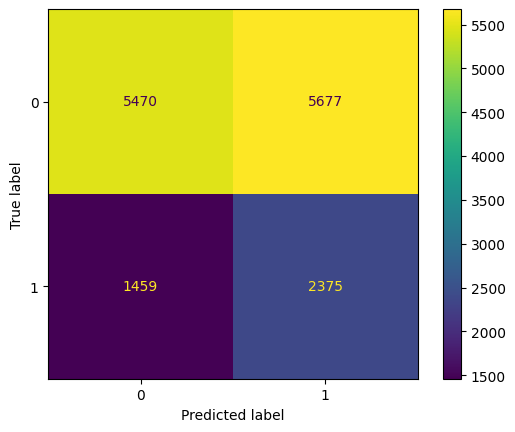

In [50]:
# 8. Avaliação e Exibição dos Resultados

# Previsões do modelo completo
y_pred_pipeline = grid_search.predict(X_test)

# Função para avaliar o modelo (Matriz de Confusão + Relatório de Métricas)
def avaliar_modelo(y_true, y_pred, titulo):
    print(f"\n=== Avaliação: {titulo} ===")

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot() # (cmap='Blues')
    #plt.title(f"Matriz de Confusão - {titulo}")
    #plt.show()

    # Relatório detalhado (precision, recall, f1 para classe 0 e 1)
    report = classification_report(y_true, y_pred, target_names=['Classe 0', 'Classe 1'])
    print(report)

    TP = cm[1, 1]  # Verdadeiros Positivos (linha 1, coluna 1)
    FN = cm[1, 0]  # Falsos Negativos (linha 1, coluna 0)

    recall_classe_1 = TP / (TP + FN)

    print(f"Recall da classe 1: {recall_classe_1:.2%}")

# Avaliação do pipeline completo
avaliar_modelo(y_test, y_pred_pipeline, "Pipeline Completo")


In [51]:
# 9. Exibindo as Variáveis Selecionadas e Parâmetros Ideais

# Para pegar as variáveis corretamente após OneHotEncoder e SelectKBest
column_transformer = grid_search.best_estimator_.named_steps['preprocessing']

# Acessando o encoder no segundo transformer, que é o de variáveis categóricas
encoder = column_transformer.transformers_[1][1]  # O [1][1] pega o OneHotEncoder

# Obtendo os nomes das variáveis geradas pelo OneHotEncoder
encoded_cat_features = encoder.get_feature_names_out()

# Variáveis selecionadas com base no 'k' do SelectKBest
column_names = num_features + list(encoded_cat_features)
selected_indices = grid_search.best_estimator_.named_steps['feature_selection'].get_support(indices=True)
selected_features = [column_names[i] for i in selected_indices]

print("\nVariáveis Selecionadas pelo Feature Selection (SelectKBest):")
print(selected_features)

# Melhor parâmetro encontrado pelo GridSearch
print("\nMelhores Parâmetros Encontrados pelo GridSearchCV:")
print(grid_search.best_params_)

# Importância das variáveis no modelo de regressão logística
model = grid_search.best_estimator_.named_steps['model']
importances = model.coef_[0]  # Coeficientes para a classe positiva (target = 1)

# Normalizando a importância para somar 100%
importances_normalized = (importances - np.min(importances)) / (np.max(importances) - np.min(importances)) * 100

# Criando um DataFrame com as variáveis e suas importâncias
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance (%)': importances_normalized,
    'Importance': importances
})

# Ordenando por importância
importance_df = importance_df.sort_values(by='Importance (%)', ascending=False)

# Calculando o percentual individual
#total_importance = importance_df['Importance (%)'].sum()
#importance_df['Individual Percentage (%)'] = (importance_df['Importance (%)'] / total_importance) * 100

# Exibindo a tabela de importâncias com o percentual individual
print("\nImportância das Variáveis (em %):")
print(importance_df)

# Explicando as escolhas do GridSearch
print("\nMotivo da Escolha dos Parâmetros:")
print("""
- O parâmetro 'model__C' ajusta a regularização no modelo de regressão logística.
  Valores mais baixos de 'C' significam mais regularização (redução do overfitting), enquanto valores mais altos permitem maior flexibilidade.
  O valor ótimo encontrado indica o equilíbrio entre viés e variância.

- O parâmetro 'feature_selection__k' determina o número de features selecionadas. O GridSearch seleciona a quantidade de features que maximiza o recall.
  O valor ótimo encontrado indica o número de features mais relevantes para o modelo, garantindo que ele utilize apenas as variáveis mais informativas.
""")



Variáveis Selecionadas pelo Feature Selection (SelectKBest):
['ESTADO_CIVIL_1', 'ESTADO_CIVIL_2', 'ESTADO_CIVIL_3', 'ESTADO_CIVIL_4', 'TIPO_OCUPACAO_1.0', 'TEM_CARTAO_True', 'IDADE_CAT_18-30', 'IDADE_CAT_31-45', 'IDADE_CAT_46-60', 'IDADE_CAT_61-80']

Melhores Parâmetros Encontrados pelo GridSearchCV:
{'feature_selection__k': 10, 'model__C': 0.01}

Importância das Variáveis (em %):
             Feature  Importance (%)  Importance
0     ESTADO_CIVIL_1      100.000000    0.185411
6    IDADE_CAT_18-30       86.524209    0.083474
3     ESTADO_CIVIL_4       80.153703    0.035285
1     ESTADO_CIVIL_2       73.231045   -0.017081
7    IDADE_CAT_31-45       62.071953   -0.101494
4  TIPO_OCUPACAO_1.0       59.312803   -0.122365
2     ESTADO_CIVIL_3       50.453134   -0.189384
5    TEM_CARTAO_True       47.513610   -0.211620
8    IDADE_CAT_46-60       25.090286   -0.381240
9    IDADE_CAT_61-80        0.000000   -0.571034

Motivo da Escolha dos Parâmetros:

- O parâmetro 'model__C' ajusta a regula